In [4]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# !pip install scikit-learn
# !pip install xgboost
# !pip install seaborn
! pip install graphviz


In [1]:
import pandas as pd
import os 
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}") 


Training on: cuda


In [2]:

df=pd.read_csv("./data/"+os.listdir("./data")[0])

df = df.sort_values(['item', 'date'])
df=pd.read_csv("./data/"+os.listdir("./data")[0])
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df = df.sort_values(['item', 'date'])

df['day_of_week']    = df['date'].dt.dayofweek
df['month']          = df['date'].dt.month
df['quarter']        = df['date'].dt.quarter
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = (df['date'].dt.day <= 5).astype(int)
df['is_month_end']   = (df['date'].dt.day >= 25).astype(int)
grp = df.groupby(['item'])['sales']
df['lag_7'] = grp.shift(7)
df['lag_14']= grp.shift(14)
df['lag_30'] = grp.shift(30)
df['lag_365'] = grp.shift(365)
df['rolling_mean_7'] = grp.shift(1).rolling(7).mean()
df['rolling_mean_30']= grp.shift(1).rolling(30).mean()
df['rolling_mean_90']= grp.shift(1).rolling(90).mean()
df['rolling_std_7']  = grp.shift(1).rolling(7).std()
df['trend_direction']= df['lag_7'] - df['lag_30']
df['yoy_growth']     = (df['lag_7'] - df['lag_365']) / (df['lag_365'] + 1)

df['sales_next_7']   = grp.shift(-7).rolling(7).sum()

df.dropna(inplace=True)

FEATURES = ['day_of_week','month','quarter','is_weekend',
            'is_month_start','is_month_end','lag_7','lag_14',
            'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
            'rolling_mean_90','rolling_std_7',
            'trend_direction','yoy_growth']
TARGET = 'sales_next_7'

X = df[FEATURES].values
y = df[TARGET].values
if("store" in df.columns):df.drop(columns="store", inplace=True)

In [5]:
df

,date,item,sales,day_of_week,month,quarter,is_weekend,is_month_start,is_month_end,lag_7,lag_14,lag_30,lag_365,rolling_mean_7,rolling_mean_30,rolling_mean_90,rolling_std_7,trend_direction,yoy_growth,sales_next_7
9166,2013-02-06,1,7,2,2,1,0,0,0,18.0,16.0,12.0,13.0,13.571429,13.600000,13.544444,3.457222,6.0,0.357143,81.0
10992,2013-02-06,1,6,2,2,1,0,0,0,10.0,17.0,13.0,12.0,12.000000,13.433333,13.522222,3.605551,-3.0,-0.153846,90.0
12818,2013-02-06,1,10,2,2,1,0,0,0,10.0,11.0,22.0,19.0,11.428571,13.200000,13.455556,4.237025,-12.0,-0.450000,93.0
14644,2013-02-06,1,8,2,2,1,0,0,0,12.0,10.0,27.0,10.0,11.428571,12.800000,13.455556,4.237025,-15.0,0.181818,93.0
16470,2013-02-06,1,15,2,2,1,0,0,0,15.0,9.0,20.0,11.0,10.857143,12.166667,13.333333,4.413184,-5.0,0.333333,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911172,2017-12-30,50,62,5,12,4,1,0,1,79.0,37.0,52.0,85.0,60.285714,59.533333,56.477778,13.646908,27.0,-0.069767,419.0
912998,2017-12-30,50,62,5,12,4,1,0,1,62.0,43.0,63.0,65.0,57.857143,59.866667,56.555556,11.021624,-1.0,-0.045455,403.0
896565,2017-12-31,50,45,6,12,4,1,0,1,66.0,44.0,52.0,70.0,57.857143,59.833333,56.544444,11.021624,14.0,-0.056338,434.0
898391,2017-12-31,50,73,6,12,4,1,0,1,60.0,80.0,68.0,71.0,54.857143,59.600000,56.388889,11.290535,-8.0,-0.152778,426.0


Training samples: 715,520 | Test samples: 178,880
------------------------------------------------------------
Epoch  10/350 | Train Loss: 0.0154 | Val Loss: 0.0149
Epoch  20/350 | Train Loss: 0.0074 | Val Loss: 0.0035
Epoch  30/350 | Train Loss: 0.0043 | Val Loss: 0.0036
Epoch  40/350 | Train Loss: 0.0039 | Val Loss: 0.0027
Epoch  50/350 | Train Loss: 0.0034 | Val Loss: 0.0022
Epoch  60/350 | Train Loss: 0.0031 | Val Loss: 0.0022
Epoch  70/350 | Train Loss: 0.0030 | Val Loss: 0.0019
Epoch  80/350 | Train Loss: 0.0028 | Val Loss: 0.0019
Epoch  90/350 | Train Loss: 0.0027 | Val Loss: 0.0019
Epoch 100/350 | Train Loss: 0.0026 | Val Loss: 0.0018
Epoch 110/350 | Train Loss: 0.0025 | Val Loss: 0.0018
Epoch 120/350 | Train Loss: 0.0024 | Val Loss: 0.0017
Epoch 130/350 | Train Loss: 0.0023 | Val Loss: 0.0016
Epoch 140/350 | Train Loss: 0.0022 | Val Loss: 0.0016
Epoch 150/350 | Train Loss: 0.0021 | Val Loss: 0.0016
Epoch 160/350 | Train Loss: 0.0020 | Val Loss: 0.0016
Epoch 170/350 | Train Los

/tmp/ipykernel_8536/1930382592.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Within {t}%' for t in thresholds], y=accuracies, ax=axes[2], palette="viridis")


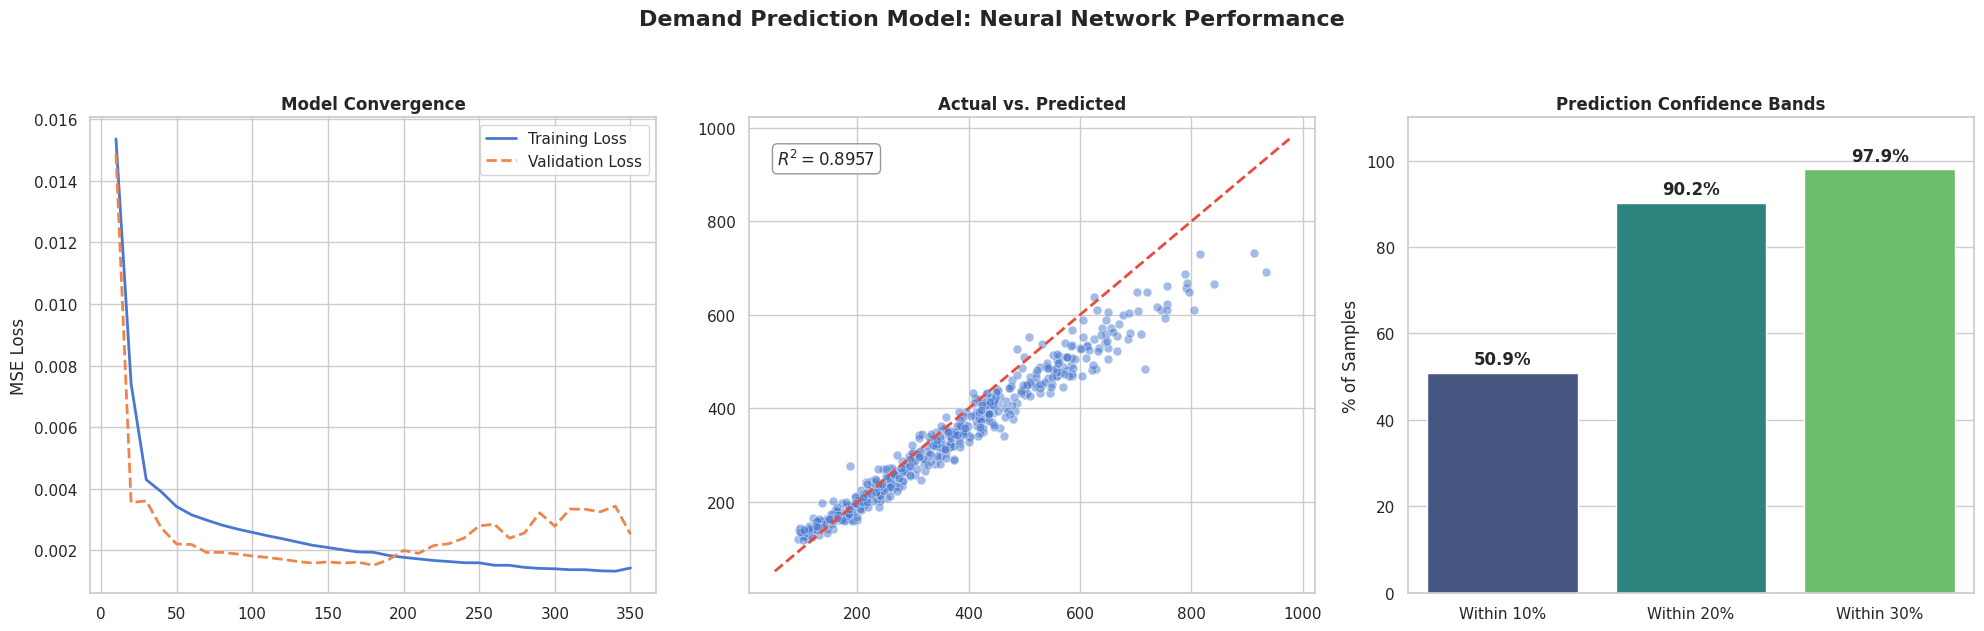

Model saved: demand_model.pth
Scalers saved: scaler_X.pkl, scaler_y.pkl


In [6]:

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

class DemandANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DemandANN(len(FEATURES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

train_losses = []
val_losses   = []
epochs_log   = []


print(f"Training samples: {len(X_train):,} | Test samples: {len(X_test):,}")
print("-" * 60)

for epoch in range(350):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = loss_fn(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_preds = model(X_test_t)
            val_loss  = loss_fn(val_preds, y_test_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        epochs_log.append(epoch + 1)

        print(f"Epoch {epoch+1:3d}/350 | "
              f"Train Loss: {loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f}")

print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()
    y_true_scaled = y_test_t.cpu().numpy()

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2 = r2_score(y_true_real, y_pred_real)

thresholds = [10, 20, 30]
accuracies = []

for t in thresholds:
    relative_error = np.abs(y_true_real - y_pred_real) / np.maximum(np.abs(y_true_real), 1e-9)
    within_tol = relative_error <= (t / 100.0)
    accuracies.append(np.mean(within_tol) * 100)

accuracy_20 = accuracies[1] 

print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")
print(f"Accuracy (within 20%): {accuracy_20:.2f}%")

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Demand Prediction Model: Neural Network Performance', fontsize=16, fontweight='bold', y=1.05)

sns.lineplot(x=epochs_log, y=train_losses, ax=axes[0], label='Training Loss', lw=2)
sns.lineplot(x=epochs_log, y=val_losses, ax=axes[0], label='Validation Loss', lw=2, linestyle='--')
axes[0].set_title('Model Convergence', fontweight='bold')
axes[0].set_ylabel('MSE Loss')

sample_size = min(500, len(y_true_real))
idx = np.random.choice(len(y_true_real), sample_size, replace=False)

sns.scatterplot(x=y_true_real[idx].flatten(), y=y_pred_real[idx].flatten(), 
                ax=axes[1], alpha=0.5, edgecolor='w', s=40)

lims = [np.min([axes[1].get_xlim(), axes[1].get_ylim()]), 
        np.max([axes[1].get_xlim(), axes[1].get_ylim()])]
axes[1].plot(lims, lims, color='#e74c3c', lw=2, ls='--', label='Perfect Fit')
axes[1].set_title('Actual vs. Predicted', fontweight='bold')
axes[1].annotate(f'$R^2 = {r2:.4f}$', xy=(0.05, 0.9), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

sns.barplot(x=[f'Within {t}%' for t in thresholds], y=accuracies, ax=axes[2], palette="viridis")
axes[2].set_title('Prediction Confidence Bands', fontweight='bold')
axes[2].set_ylabel('% of Samples')
axes[2].set_ylim(0, 110)

for i, val in enumerate(accuracies):
    axes[2].text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), 'demand_model.pth')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Model saved: demand_model.pth")
print("Scalers saved: scaler_X.pkl, scaler_y.pkl")


XGBoost Performance
MAE  : 19.58
RMSE : 26.44
R²   : 0.9780
Accuracy (within 20%) : 97.43%
Accuracy (within 5%)  : 53.08%
Accuracy (within 10%) : 82.64%
Accuracy (within 20%) : 97.43%
         date  item  predicted_demand
37 2018-02-07     1         95.336548
38 2018-02-08     1         92.769867
39 2018-02-09     1        109.103615
40 2018-02-10     1        110.396561
41 2018-02-11     1        102.375038


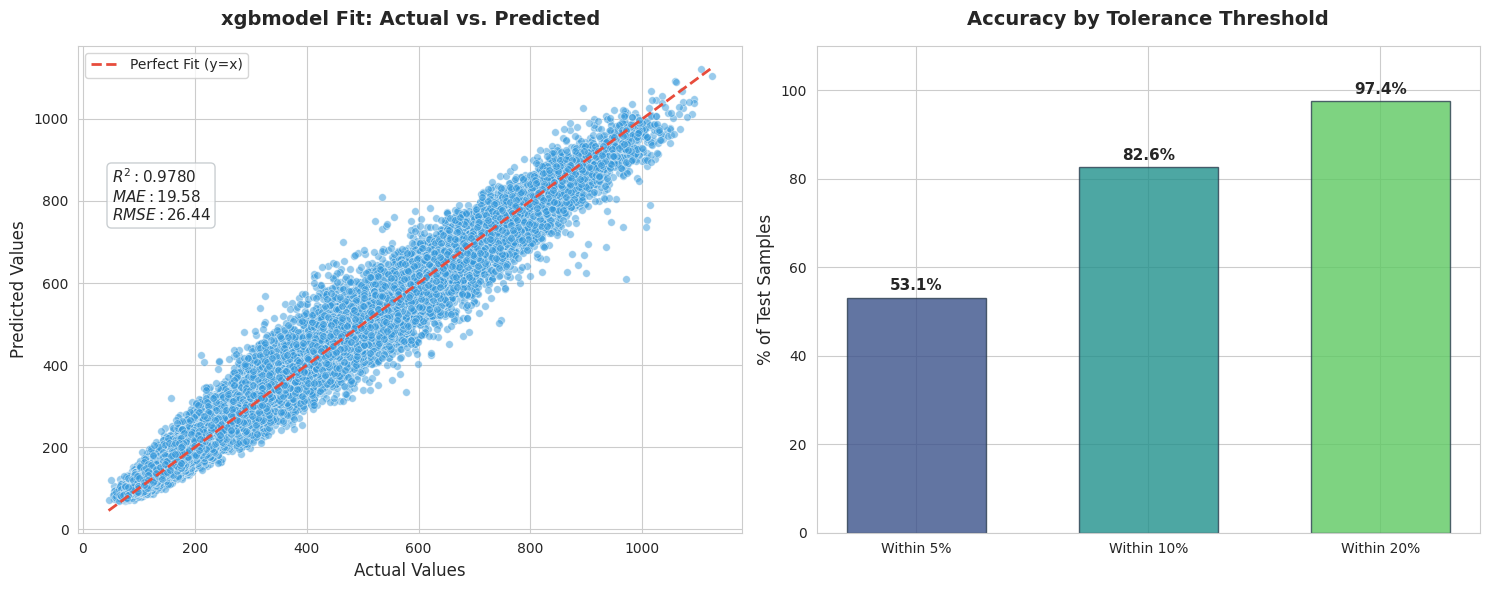

xgbmodel saved: xgb_model.pkl


<Figure size 10000x10000 with 0 Axes>

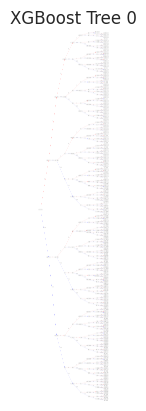

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgbmodel = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9
)

xgbmodel.fit(X_train, y_train)

y_pred = xgbmodel.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

within_20 = np.abs(y_pred - y_test) <= (0.2 * np.abs(y_test))
accuracy_20 = np.mean(within_20) * 100

print("\nXGBoost Performance")
print("="*40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"Accuracy (within 20%) : {accuracy_20:.2f}%")
within_10 = np.abs(y_pred - y_test) <= (0.1 * np.abs(y_test))
accuracy_10 = np.mean(within_10) * 100

within_5 = np.abs(y_pred - y_test) <= (0.05 * np.abs(y_test))
accuracy_5 = np.mean(within_5) * 100

print(f"Accuracy (within 5%)  : {accuracy_5:.2f}%")
print(f"Accuracy (within 10%) : {accuracy_10:.2f}%")
print(f"Accuracy (within 20%) : {accuracy_20:.2f}%")


import pandas as pd
import numpy as np

test_data = pd.read_csv("./data/test.csv")
test_data.drop(columns="store", inplace=True)
test_data['date'] = pd.to_datetime(test_data['date'], format='%d/%m/%Y')

test_data['day_of_week']    = test_data['date'].dt.dayofweek
test_data['month']          = test_data['date'].dt.month
test_data['quarter']        = test_data['date'].dt.quarter
test_data['is_weekend']     = (test_data['day_of_week'] >= 5).astype(int)
test_data['is_month_start'] = (test_data['date'].dt.day <= 5).astype(int)
test_data['is_month_end']   = (test_data['date'].dt.day >= 25).astype(int)



test_data['lag_7']   = grp.shift(7)
test_data['lag_14']  = grp.shift(14)
test_data['lag_30']  = grp.shift(30)
test_data['lag_365'] = grp.shift(365)

test_data['rolling_mean_7']  = grp.shift(1).transform(lambda x: x.rolling(7).mean())
test_data['rolling_mean_30'] = grp.shift(1).transform(lambda x: x.rolling(30).mean())
test_data['rolling_mean_90'] = grp.shift(1).transform(lambda x: x.rolling(90).mean())
test_data['rolling_std_7']   = grp.shift(1).transform(lambda x: x.rolling(7).std())

test_data['trend_direction'] = test_data['lag_7'] - test_data['lag_30']
test_data['yoy_growth']      = (test_data['lag_7'] - test_data['lag_365']) / (test_data['lag_365'] + 1)

test_data.dropna(inplace=True)

FEATURES = ['day_of_week','month','quarter','is_weekend',
            'is_month_start','is_month_end','lag_7','lag_14',
            'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
            'rolling_mean_90','rolling_std_7',
            'trend_direction','yoy_growth']

X_predict = test_data[FEATURES]
predictions = xgbmodel.predict(X_predict)

test_data['predicted_demand'] = predictions
print(test_data[['date', 'item', 'predicted_demand']].head())





sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=30, color='#3498db', edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], '--', color='#e74c3c', lw=2, label='Perfect Fit (y=x)')

axes[0].set_title('xgbmodel Fit: Actual vs. Predicted', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].legend(loc='upper left')

stats_text = f'$R^2: {r2:.4f}$\n$MAE: {mae:.2f}$\n$RMSE: {rmse:.2f}$'
axes[0].text(0.05, 0.75, stats_text, transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

thresholds = [5, 10, 20]
acc_values = [accuracy_5, accuracy_10, accuracy_20]
labels = [f'Within {t}%' for t in thresholds]

# Use a professional color palette
colors = sns.color_palette("viridis", len(thresholds))
bars = axes[1].bar(labels, acc_values, color=colors, edgecolor='#2c3e50', alpha=0.8, width=0.6)

axes[1].set_title('Accuracy by Tolerance Threshold', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('% of Test Samples', fontsize=12)
axes[1].set_ylim(0, 110) 
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

joblib.dump(xgbmodel, 'xgbmodel.pkl')
print("xgbmodel saved: xgb_model.pkl")
from xgboost import plot_importance
import matplotlib.pyplot as plt
from xgboost import plot_tree

plt.figure(figsize=(100, 100))

plot_tree(
    xgbmodel,
    tree_idx=0,
    rankdir="LR"
)

plt.title("XGBoost Tree 0")

# Save image
plt.savefig("xgboost_tree_0.png", dpi=300, bbox_inches="tight")

plt.show()

Predict future--ANN

In [5]:
import numpy as np
import torch

FEATURES = ['day_of_week','month','quarter','is_weekend',
            'is_month_start','is_month_end','lag_7','lag_14',
            'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
            'rolling_mean_90','rolling_std_7',
            'trend_direction','yoy_growth']

def predict_batch(list_of_feature_dicts, horizon='week'):

    def predict_one_week_ann(current_features):
        raw_data = [[item[feat] for feat in FEATURES] for item in current_features]
        scaled_data = scaler_X.transform(raw_data)
        tensor_data = torch.FloatTensor(scaled_data).to(device)
        with torch.no_grad():
            scaled_predictions = model(tensor_data)
        real_predictions = scaler_y.inverse_transform(scaled_predictions.cpu().numpy())
        return [round(float(pred[0])) for pred in real_predictions]

    def predict_one_week_xgb(current_features):
        raw_data = [[item[feat] for feat in FEATURES] for item in current_features]
        input_data = np.array(raw_data)
        
        preds = xgbmodel.predict(input_data)
        return [round(float(p)) for p in preds]

    def update_features_for_next_week(old_features, predicted_weekly_sales):
        new_features = old_features.copy()
        daily_sales = predicted_weekly_sales / 7

        new_features['lag_14'] = new_features['lag_7']
        new_features['lag_7']  = daily_sales
        new_features['lag_30'] = (new_features['lag_30'] * 3 + predicted_weekly_sales) / 4

        new_features['rolling_mean_7']  = (new_features['rolling_mean_7'] * 6 + daily_sales) / 7
        new_features['rolling_mean_30'] = (new_features['rolling_mean_30'] * 29 + daily_sales) / 30
        new_features['trend_direction'] = new_features['lag_7'] - new_features['lag_30']

        new_features['day_of_week'] = (new_features['day_of_week'] + 7) % 7
        new_features['is_weekend']  = 1 if new_features['day_of_week'] >= 5 else 0

        return new_features

    results = [{'weekly': 0, 'monthly': 0, 'weekly_breakdown': [], 'daily_breakdown': []} for _ in list_of_feature_dicts]
    current_features = [f.copy() for f in list_of_feature_dicts]

    for week_num in range(4):

        week_predictions = predict_one_week_xgb(current_features)
        
        for i in range(len(list_of_feature_dicts)):
            weekly_val = week_predictions[i]
            
            if week_num == 0:
                results[i]['weekly'] = weekly_val
            
            results[i]['monthly'] += weekly_val
            results[i]['weekly_breakdown'].append(weekly_val)
            
            daily_avg = round(weekly_val / 7, 2)
            results[i]['daily_breakdown'].extend([daily_avg] * 7)
            
            current_features[i] = update_features_for_next_week(current_features[i], weekly_val)

    if horizon == 'week':
        return [{'weekly': r['weekly'], 'daily': r['daily_breakdown'][:7]} for r in results]
    elif horizon == 'month':
        return [{'monthly': r['monthly'], 'weekly_breakdown': r['weekly_breakdown'], 'daily_breakdown': r['daily_breakdown']} for r in results]
    elif horizon == 'both':
        return results
    else:
        raise ValueError("Horizon must be 'week', 'month', or 'both'")


products = [
    {
        'day_of_week':1, 'month':12, 'quarter':4, 'is_weekend':0,
        'is_month_start':0, 'is_month_end':1, 'lag_7':48, 'lag_14':44,
        'lag_30':41, 'lag_365':31, 'rolling_mean_7':44.2, 'rolling_mean_90':73,
        'rolling_mean_30':39.7, 'rolling_std_7':4.1,
        'trend_direction':7.0, 'yoy_growth':0.61
    },
    {
        'day_of_week':3, 'month':10, 'quarter':4, 'is_weekend':0,
        'is_month_start':0, 'is_month_end':0, 'lag_7':80, 'lag_14':75,
        'lag_30':60, 'lag_365':70, 'rolling_mean_7':77.0, 'rolling_mean_90':73,
        'rolling_mean_30':65.0, 'rolling_std_7':6.2,
        'trend_direction':20.0, 'yoy_growth':0.14
    },
    {
        'day_of_week':0, 'month':1, 'quarter':1, 'is_weekend':0,
        'is_month_start':1, 'is_month_end':0, 'lag_7':20, 'lag_14':22,
        'lag_30':25, 'lag_365':21, 'rolling_mean_7':21.0, 'rolling_mean_90':73,
        'rolling_mean_30':23.0, 'rolling_std_7':1.8,
        'trend_direction':-5.0, 'yoy_growth':-0.05
    }
]

names = ['Wireless Headphones', 'Rice Bags', 'LED Bulbs']
results = predict_batch(products, horizon='both')

print("\n" + "="*65)
print("DEMAND PREDICTIONS")
print("="*65)
print(f"{'Product':<25} {'Next Week':>12} {'Next Month':>12} {'Trend':>10}")
print("-"*65)

for name, result in zip(names, results):
    weekly, monthly, wb = result['weekly'], result['monthly'], result['weekly_breakdown']
    trend = "rising" if wb[-1] > wb[0] else "falling" if wb[-1] < wb[0] else "stable"
    print(f"{name:<25} {weekly:>10} units {monthly:>10} units {trend:>10}")
    for name, res in zip(names, results):
        print(f"{name} - First 3 days of Month: {res['daily_breakdown'][:3]}")

print("="*65)
print("\nWEEKLY BREAKDOWN FOR NEXT MONTH")
print("="*65)
print(f"{'Product':<25} {'Week 1':>10} {'Week 2':>10} {'Week 3':>10} {'Week 4':>10}")
print("-"*65)

for name, result in zip(names, results):
    wb = result['weekly_breakdown']
    print(f"{name:<25} {wb[0]:>8} units {wb[1]:>8} units {wb[2]:>8} units {wb[3]:>8} units")
print("="*65)


DEMAND PREDICTIONS
Product                      Next Week   Next Month      Trend
-----------------------------------------------------------------
Wireless Headphones              376 units       1513 units     rising
Wireless Headphones - First 3 days of Month: [53.71, 53.71, 53.71]
Rice Bags - First 3 days of Month: [75.14, 75.14, 75.14]
LED Bulbs - First 3 days of Month: [56.14, 56.14, 56.14]
Rice Bags                        526 units       2051 units    falling
Wireless Headphones - First 3 days of Month: [53.71, 53.71, 53.71]
Rice Bags - First 3 days of Month: [75.14, 75.14, 75.14]
LED Bulbs - First 3 days of Month: [56.14, 56.14, 56.14]
LED Bulbs                        393 units       1566 units     stable
Wireless Headphones - First 3 days of Month: [53.71, 53.71, 53.71]
Rice Bags - First 3 days of Month: [75.14, 75.14, 75.14]
LED Bulbs - First 3 days of Month: [56.14, 56.14, 56.14]

WEEKLY BREAKDOWN FOR NEXT MONTH
Product                       Week 1     Week 2     Week 3    

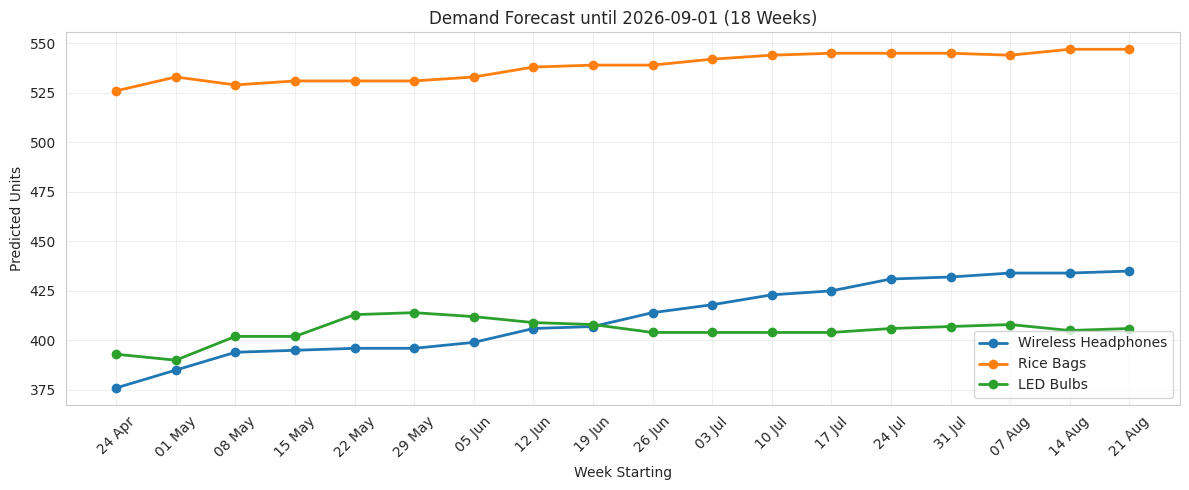


Product                      Total Demand
---------------------------------------------
Wireless Headphones               7400 units
Rice Bags                         9689 units
LED Bulbs                         7291 units


In [6]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

def predict_until_date(list_of_feature_dicts, target_date, names=None):
    if isinstance(target_date, str):
        target_date = datetime.strptime(target_date, '%Y-%m-%d')
    
    today = datetime.today()
    days_ahead = (target_date - today).days
    
    if days_ahead <= 0:
        print("Error: Target date must be in the future.")
        return None

    num_weeks = max(1, round(days_ahead / 7))
    pnames = names or [f'Product {i+1}' for i in range(len(list_of_feature_dicts))]
    
    def get_xgb_prediction(current_features):
        raw_data = [[item[feat] for feat in FEATURES] for item in current_features]
        preds = xgbmodel.predict(np.array(raw_data))
        return [round(float(p)) for p in preds]

    def update_features(f, weekly_pred):
        f = f.copy()
        daily_avg = weekly_pred / 7
        f['lag_14'] = f['lag_7']
        f['lag_7'] = daily_avg
        f['rolling_mean_7'] = (f['rolling_mean_7'] * 6 + daily_avg) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily_avg) / 30
        f['trend_direction'] = f['lag_7'] - f['lag_30']

        f['day_of_week'] = (f['day_of_week'] + 7) % 7
        f['is_weekend'] = 1 if f['day_of_week'] >= 5 else 0
        return f

    current_features = [f.copy() for f in list_of_feature_dicts]
    weekly_matrix = [[] for _ in range(len(list_of_feature_dicts))]
    week_labels = [(today + timedelta(weeks=w)).strftime('%d %b') for w in range(num_weeks)]

    for _ in range(num_weeks):
        preds = get_xgb_prediction(current_features)
        for i, p in enumerate(preds):
            weekly_matrix[i].append(p)
            current_features[i] = update_features(current_features[i], p)

    plt.figure(figsize=(12, 5))
    
    for i, name in enumerate(pnames):
        plt.plot(week_labels, weekly_matrix[i], marker='o', label=name, linewidth=2)
        
    plt.title(f'Demand Forecast until {target_date.strftime("%Y-%m-%d")} ({num_weeks} Weeks)')
    plt.xlabel('Week Starting')
    plt.ylabel('Predicted Units')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if num_weeks > 6:
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

    print(f"\n{'Product':<25} {'Total Demand':>15}")
    print("-" * 45)
    for i, name in enumerate(pnames):
        print(f"{name:<25} {sum(weekly_matrix[i]):>12} units")

predict_until_date(products, '2026-09-01', names=names)

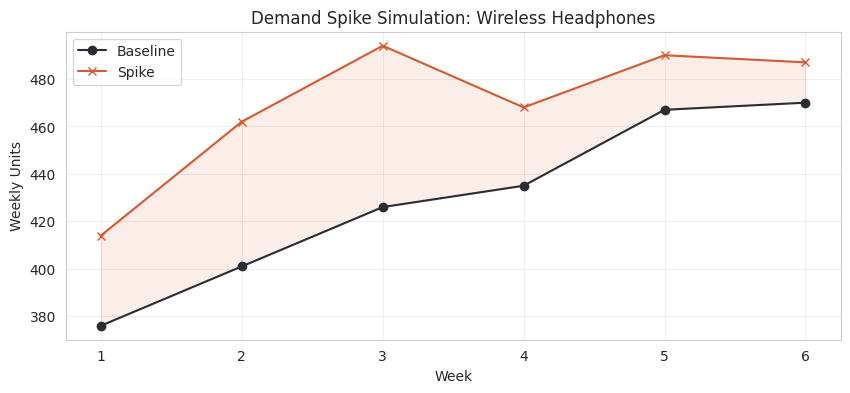

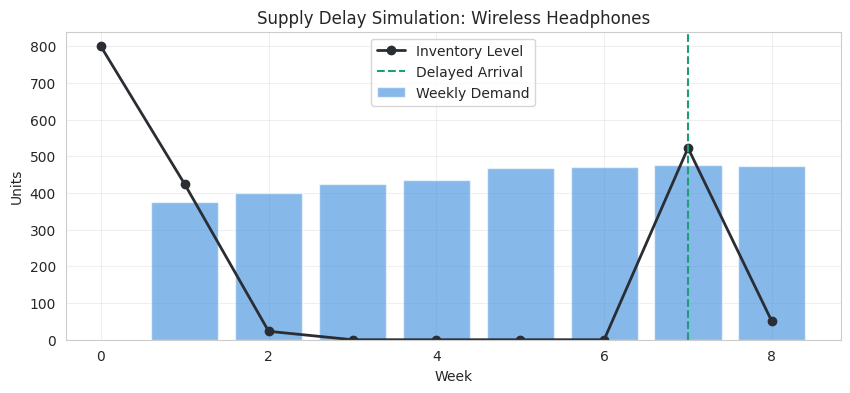

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_xgb_prediction(f, model):
    features = ['day_of_week', 'month', 'quarter', 'is_weekend',
                'is_month_start', 'is_month_end', 'lag_7', 'lag_14',
                'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30',
                'rolling_mean_90', 'rolling_std_7', 'trend_direction', 'yoy_growth']
    
    arr = np.array([[f[feat] for feat in features]])
    pred = model.predict(arr)[0]
    return round(float(pred))

def update_features_for_next_week(f, weekly_sales):
    new_f = f.copy()
    daily_avg = weekly_sales / 7
    
    new_f['lag_30'] = new_f['lag_14']
    new_f['lag_14'] = new_f['lag_7']
    new_f['lag_7']  = daily_avg
    
    new_f['rolling_mean_7']  = daily_avg
    new_f['rolling_mean_30'] = (new_f['rolling_mean_30'] * 23 + (daily_avg * 7)) / 30
    new_f['rolling_mean_90'] = (new_f['rolling_mean_90'] * 83 + (daily_avg * 7)) / 90
    
    raw_trend = new_f['lag_7'] - new_f['lag_30']
    new_f['trend_direction'] = max(min(raw_trend, 5.0), -5.0)
    
    new_f['day_of_week'] = (new_f['day_of_week'] + 7) % 7
    new_f['is_weekend'] = 1 if new_f['day_of_week'] >= 5 else 0
    
    new_f['month'] += 0.25 
    if new_f['month'] > 12.75: 
        new_f['month'] = 1
    new_f['quarter'] = (int(new_f['month']) - 1) // 3 + 1
    
    return new_f

def scenario_demand_spike(feature_dict, model, product_name, spike_percent=50, spike_duration_weeks=2):
    num_weeks = 6
    normal_preds, spike_preds = [], []
    f_n, f_s = feature_dict.copy(), feature_dict.copy()
    multiplier = 1 + (spike_percent / 100)

    for w in range(num_weeks):
        pn = get_xgb_prediction(f_n, model)
        normal_preds.append(pn)
        f_n = update_features_for_next_week(f_n, pn)
        
        ps_base = get_xgb_prediction(f_s, model)
        ps_final = round(ps_base * multiplier) if w < spike_duration_weeks else ps_base
        spike_preds.append(ps_final)
        f_s = update_features_for_next_week(f_s, ps_final)

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, 7), normal_preds, label='Baseline', color='#2a2e34', marker='o')
    plt.plot(range(1, 7), spike_preds, label='Spike', color='#D85A30', marker='x')
    plt.fill_between(range(1, 7), normal_preds, spike_preds, color='#D85A30', alpha=0.1)
    plt.title(f"Demand Spike Simulation: {product_name}")
    plt.ylabel("Weekly Units")
    plt.xlabel("Week")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def scenario_supply_delay(feature_dict, model, product_name, current_stock=240, restock_qty=500, delay_weeks=3):
    num_weeks = 8
    f = feature_dict.copy()
    demand_preds = []
    
    for _ in range(num_weeks):
        p = get_xgb_prediction(f, model)
        demand_preds.append(p)
        f = update_features_for_next_week(f, p)

    stock_levels = [current_stock]
    actual_arrival = 2 + delay_weeks
    
    for w in range(1, num_weeks + 1):
        current_inv = stock_levels[-1]
        if w == actual_arrival:
            current_inv += restock_qty
            
        demand = demand_preds[w-1]
        new_inv = max(0, current_inv - demand)
        stock_levels.append(new_inv)

    plt.figure(figsize=(10, 4))
    plt.bar(range(1, num_weeks + 1), demand_preds, color='#378ADD', label='Weekly Demand', alpha=0.6)
    plt.plot(range(0, num_weeks + 1), stock_levels, color='#2a2e34', marker='o', linewidth=2, label='Inventory Level')
    plt.axvline(x=actual_arrival, color='#1D9E75', linestyle='--', label='Delayed Arrival')
    plt.title(f"Supply Delay Simulation: {product_name}")
    plt.ylabel("Units")
    plt.xlabel("Week")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

sample_product = {
    'day_of_week':1,'month':12,'quarter':4,'is_weekend':0,
    'is_month_start':0,'is_month_end':1,'lag_7':48,'lag_14':44,
    'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,'rolling_mean_90':73,
    'rolling_mean_30':39.7,'rolling_std_7':4.1,
    'trend_direction':7.0,'yoy_growth':0.61
}

scenario_demand_spike(sample_product, xgbmodel, 'Wireless Headphones', 10,3)
scenario_supply_delay(sample_product, xgbmodel, 'Wireless Headphones', 800, 1000, 5)

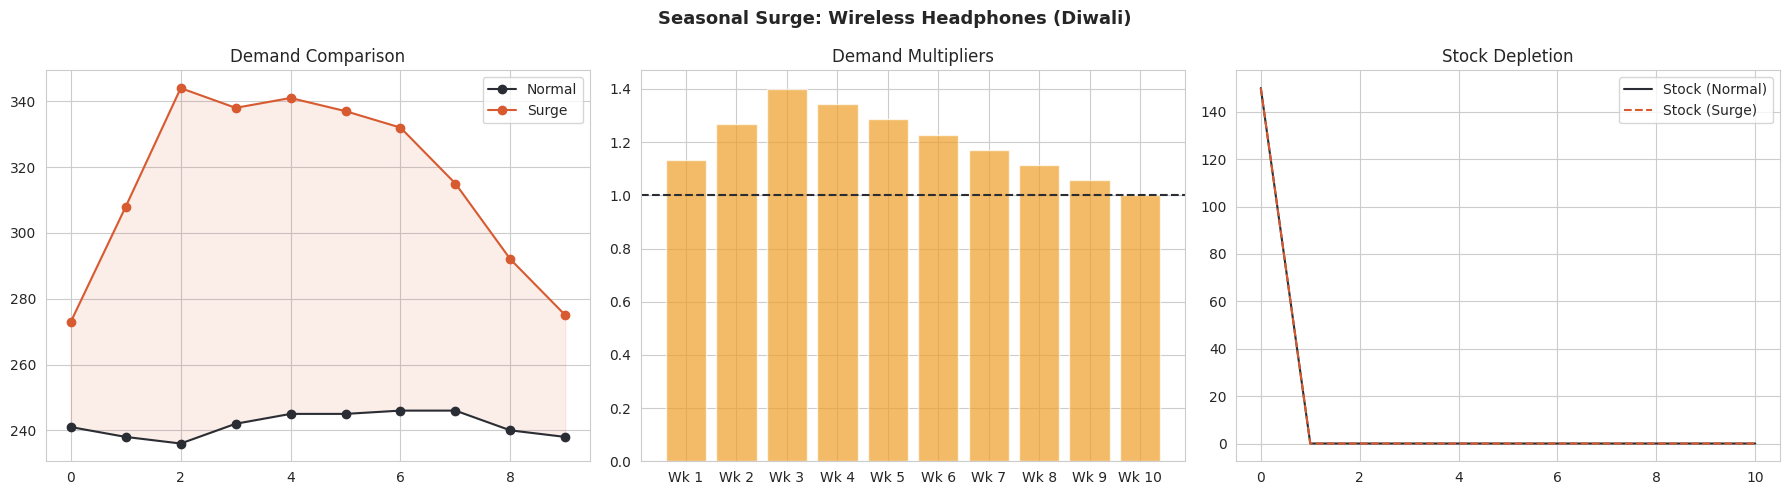


SCENARIO: NEW PRODUCT LAUNCH — Smart Watch Pro
Category: Electronics | Launch month: 10 | Growth rate: +3%/week
Week          Predicted   Confidence    Stock After
----------------------------------------------------------------------
Week 1             88 u          35%           412 u
Week 2             91 u          42%           321 u
Week 3             94 u          49%           227 u
Week 4             96 u          56%           131 u
Week 5            220 u          63%           411 u + 500 restock
Week 6            324 u          70%           587 u + 500 restock
Week 7            428 u          77%           159 u
Week 8            530 u          84%           129 u + 500 restock

Launch analysis:
  Initial stock order:     500 units
  Week 1 demand:           88 units (30% of Electronics baseline)
  Week 8 demand (mature):  530 units
  Avg weekly demand:       234 units
  Restock events:          3

AI rack recommendation:
  Recommended rack:        Rack 1A or 1B
  Zone: 

/tmp/ipykernel_50707/637699406.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(week_labels, rotation=30, ha='right')


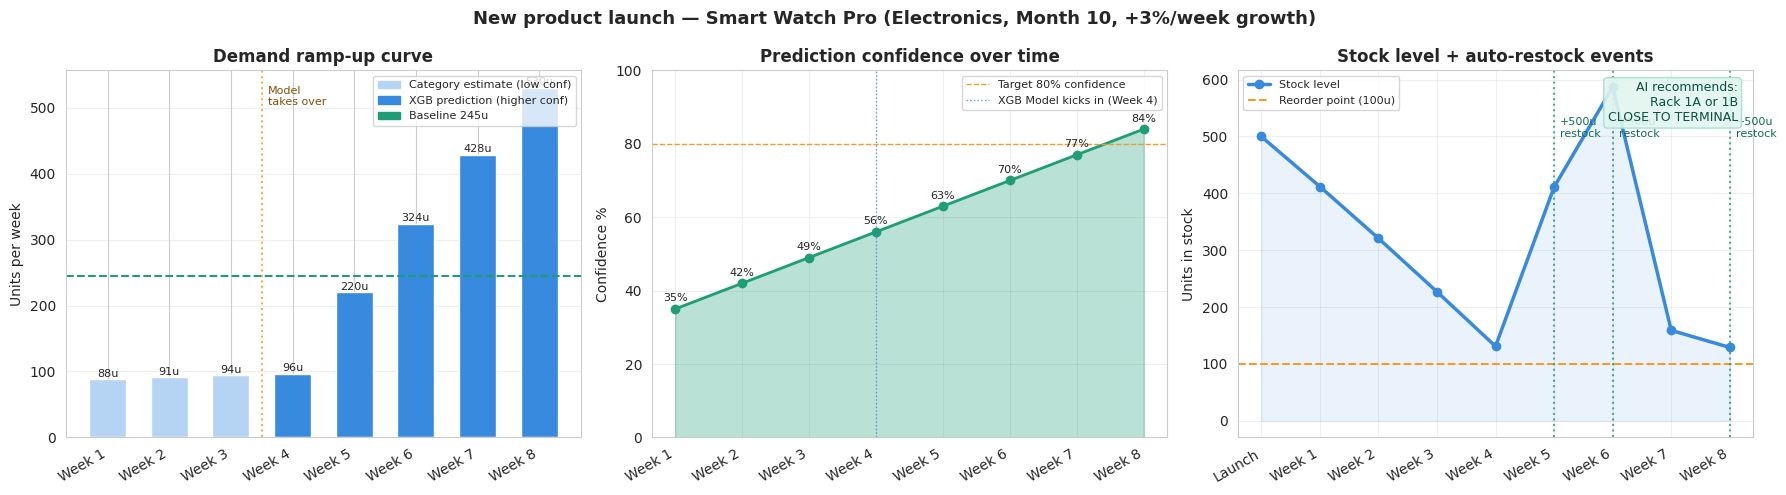

{'weekly_demand': [88, 91, 94, 96, 220, 324, 428, 530],
 'recommended_rack': 'Rack 1A or 1B'}

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FEATURES = [
    'day_of_week', 'month', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end', 'lag_7', 'lag_14',
    'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30',
    'rolling_mean_90', 'rolling_std_7', 'trend_direction', 'yoy_growth'
]

def get_xgb_prediction_single(feature_dict):
    df_input = pd.DataFrame([feature_dict])[FEATURES]
    prediction = xgbmodel.predict(df_input)[0]
    
    return prediction

def predict_weekly_xgb(f):

    daily_pred = get_xgb_prediction(f)

    return round(daily_pred * 7)

def simulate_next_week_logic(f, weekly_pred):
    f = f.copy()
    daily = weekly_pred / 7

    max_allowed_daily = f['lag_7'] * 1.5 
    daily_clamped = min(daily, max_allowed_daily)
    f['lag_30'] = f.get('lag_14', f['lag_7'])
    f['lag_14'] = f['lag_7']
    f['lag_7']  = daily_clamped
    f['rolling_mean_7']  = (f['rolling_mean_7'] * 6 + daily_clamped) / 7
    f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily_clamped) / 30
    f['day_of_week'] = (f['day_of_week'] + 7) % 7
    return f
def predict_weekly_xgb(f):
    f_ordered = {feat: f[feat] for feat in FEATURES}
    daily_pred = get_xgb_prediction_single(f_ordered)
    weekly_pred = round(daily_pred * 7) 
    
    return weekly_pred



def scenario_seasonal_surge(feature_dict, model, product_name,
                             current_stock=1500,
                             season_name='Diwali',
                             peak_week=3,
                             peak_boost_percent=120,
                             season_duration_weeks=6): 
    
    multipliers = []
    for w in range(season_duration_weeks):
        week_num = w + 1
        if week_num <= peak_week:
            progress = week_num / peak_week
            boost = (peak_boost_percent / 100) * progress
        else:
            remaining = season_duration_weeks - peak_week
            progress = (week_num - peak_week) / remaining
            boost = (peak_boost_percent / 100) * (1 - progress)
        multipliers.append(1 + boost)

    normal_preds = []
    surge_preds = []
    
    f_normal = feature_dict.copy()
    f_surge = feature_dict.copy()

    for w in range(season_duration_weeks):

        pn = get_xgb_prediction(f_normal, model)
        normal_preds.append(pn)
        f_normal = update_features_for_next_week(f_normal, pn)

        ps_base = get_xgb_prediction(f_surge, model)
        ps_surged = round(ps_base * multipliers[w])
        surge_preds.append(ps_surged)
        f_surge = update_features_for_next_week(f_surge, ps_surged)

    stock_normal = [current_stock]
    stock_surge = [current_stock]
    for w in range(season_duration_weeks):
        stock_normal.append(max(0, stock_normal[-1] - normal_preds[w]))
        stock_surge.append(max(0, stock_surge[-1] - surge_preds[w]))

    stockout_week = next((w+1 for w, s in enumerate(stock_surge[1:]) if s <= 0), None)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Seasonal Surge: {product_name} ({season_name})', fontsize=13, fontweight='bold')
    week_labels = [f'Wk {i+1}' for i in range(season_duration_weeks)]

    axes[0].plot(range(season_duration_weeks), normal_preds, marker='o', color='#2a2e34', label='Normal')
    axes[0].plot(range(season_duration_weeks), surge_preds, marker='o', color='#D85A30', label='Surge')
    axes[0].fill_between(range(season_duration_weeks), normal_preds, surge_preds, color='#D85A30', alpha=0.1)
    axes[0].set_title('Demand Comparison')
    axes[0].legend()

    axes[1].bar(week_labels, multipliers, color='#EF9F27', alpha=0.7)
    axes[1].axhline(y=1.0, color='#2a2e34', linestyle='--')
    axes[1].set_title('Demand Multipliers')

    axes[2].plot(range(season_duration_weeks + 1), stock_normal, color='#2a2e34', label='Stock (Normal)')
    axes[2].plot(range(season_duration_weeks + 1), stock_surge, color='#D85A30', linestyle='--', label='Stock (Surge)')
    axes[2].set_title('Stock Depletion')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return {'surge_weekly': surge_preds, 'stockout_week': stockout_week}

def get_xgb_prediction(f, model):
    features = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_mean_90','rolling_std_7','trend_direction','yoy_growth']
    arr = np.array([[f[feat] for feat in features]])
    return round(float(model.predict(arr)[0]))

def update_features_for_next_week(f, weekly_sales):
    new_f = f.copy()
    daily_avg = weekly_sales / 7
    new_f['lag_30'], new_f['lag_14'], new_f['lag_7'] = new_f['lag_14'], new_f['lag_7'], daily_avg
    new_f['rolling_mean_7'] = daily_avg
    new_f['rolling_mean_30'] = (new_f['rolling_mean_30'] * 23 + (daily_avg * 7)) / 30
    new_f['rolling_mean_90'] = (new_f['rolling_mean_90'] * 83 + (daily_avg * 7)) / 90
    new_f['trend_direction'] = max(min(new_f['lag_7'] - new_f['lag_30'], 5.0), -5.0)
    new_f['month'] = (new_f['month'] + 0.25) if new_f['month'] < 12.75 else 1
    return new_f


def scenario_new_product_launch(product_name,
                                 category='Electronics',
                                 launch_week_month=3,
                                 initial_stock=500,
                                 growth_rate_percent=15,
                                 num_weeks=8,
                                 **kwargs):
                                 
    category_baselines = {
        'Electronics':{'daily_avg': 35, 'volatility': 0.25},
        'Pumps':{'daily_avg': 80, 'volatility': 0.15},
        'Mechanical':{'daily_avg': 20, 'volatility': 0.10},
        'Machinery':{'daily_avg': 12, 'volatility': 0.30},
    }
    baseline = category_baselines.get(category, category_baselines['Electronics'])

    month_index = {1:0.70, 2:0.65, 3:0.75, 4:0.80, 5:0.85, 6:0.90, 7:0.92, 8:1.00, 9:1.05, 10:1.20, 11:1.40, 12:1.60}

    ramp_preds   = []
    confidence   = []
    current_month = launch_week_month
    base_daily  = baseline['daily_avg'] * 0.30 

    for w in range(num_weeks):
        if w > 0:
            base_daily = base_daily * (1 + growth_rate_percent / 100)
        base_daily = min(base_daily, baseline['daily_avg'] * 1.10)
        
        seasonal_mod = month_index.get(current_month, 1.0)
        weekly_pred  = round(base_daily * 7 * seasonal_mod)
        ramp_preds.append(weekly_pred)
        
        conf = min(85, 35 + (w * 7)) 
        confidence.append(conf)
        
        if (w + 1) % 4 == 0:
            current_month = current_month + 1 if current_month < 12 else 1

    week4_daily = ramp_preds[3] / 7 if len(ramp_preds) >= 4 else base_daily
    model_features = {
        'day_of_week':    0,
        'month':          launch_week_month,
        'quarter':        (launch_week_month - 1) // 3 + 1,
        'is_weekend':     0,
        'is_month_start': 0,
        'is_month_end':   0,
        'lag_7':          week4_daily,
        'lag_14':         week4_daily * 0.85,
        'lag_30':         week4_daily * 0.65,
        'lag_365':        0,
        'rolling_mean_7': week4_daily * 0.95,
        'rolling_mean_30':week4_daily * 0.70,
        'rolling_mean_90':week4_daily * 0.60, 
        'rolling_std_7':  week4_daily * baseline['volatility'],
        'trend_direction':week4_daily * 0.35,
        'yoy_growth':     0
    }

    model_weekly = predict_weekly_xgb(model_features)

    for w in range(4, num_weeks):
        blend_weight  = min(1.0, (w - 3) * 0.25)
        blended       = round(ramp_preds[w] * (1 - blend_weight) + model_weekly * blend_weight)
        ramp_preds[w] = blended

    # ── Stock simulation ──────────────────────────────────────
    stock_levels   = [initial_stock]
    restock_events = []
    for w in range(num_weeks):
        remaining = stock_levels[-1] - ramp_preds[w]
        if remaining < initial_stock * 0.20:
            restock_qty = initial_stock
            remaining  += restock_qty
            restock_events.append({'week': w+1, 'qty': restock_qty})
        stock_levels.append(max(0, remaining))

    # ── Rack recommendation ───────────────────────────────────
    avg_weekly     = sum(ramp_preds) / num_weeks
    mature_weekly  = ramp_preds[-1]

    if mature_weekly > baseline['daily_avg'] * 7 * 0.8:
        recommended_rack, rack_reason, rack_zone = 'Rack 1A or 1B', 'High mature demand — place near terminal', 'CLOSE TO TERMINAL'
    elif mature_weekly > baseline['daily_avg'] * 7 * 0.5:
        recommended_rack, rack_reason, rack_zone = 'Rack 2A or 2B', 'Medium demand — mid-distance placement', 'MID ZONE'
    else:
        recommended_rack, rack_reason, rack_zone = 'Rack 3A or 3B', 'Low demand — further from terminal is fine', 'FAR ZONE'

    # ── Print ─────────────────────────────────────────────────
    week_labels = [f'Week {i+1}' for i in range(num_weeks)]
    print("\n" + "="*70)
    print(f"SCENARIO: NEW PRODUCT LAUNCH — {product_name}")
    print(f"Category: {category} | Launch month: {launch_week_month} | Growth rate: +{growth_rate_percent}%/week")
    print("="*70)
    print(f"{'Week':<10} {'Predicted':>12} {'Confidence':>12} {'Stock After':>14}")
    print("-"*70)
    for w in range(num_weeks):
        re_flag = ''.join([f' + {re["qty"]} restock' for re in restock_events if re['week'] == w + 1])
        print(f"Week {w+1:<5} {ramp_preds[w]:>10} u  {confidence[w]:>10}%  {stock_levels[w+1]:>12} u{re_flag}")
    print("="*70)
    print(f"\nLaunch analysis:")
    print(f"  Initial stock order:     {initial_stock} units")
    print(f"  Week 1 demand:           {ramp_preds[0]} units (30% of {category} baseline)")
    print(f"  Week {num_weeks} demand (mature):  {ramp_preds[-1]} units")
    print(f"  Avg weekly demand:       {round(avg_weekly)} units")
    print(f"  Restock events:          {len(restock_events)}")
    print(f"\nAI rack recommendation:\n  Recommended rack:        {recommended_rack}\n  Zone:                    {rack_zone}\n  Reason:                  {rack_reason}")
    print("="*70)

    # ── Graph ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'New product launch — {product_name} ({category}, Month {launch_week_month}, +{growth_rate_percent}%/week growth)', fontsize=13, fontweight='bold')

    ax1 = axes[0]
    bar_colors = ['#B5D4F4' if w < 3 else '#378ADD' for w in range(num_weeks)]
    bars = ax1.bar(week_labels, ramp_preds, color=bar_colors, edgecolor='white', width=0.6)
    for bar, pred in zip(bars, ramp_preds):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pred}u', ha='center', va='bottom', fontsize=8)

    baseline_weekly = round(baseline['daily_avg'] * 7)
    ax1.axhline(y=baseline_weekly, color='#1D9E75', linewidth=1.5, linestyle='--', label=f'{category} baseline ({baseline_weekly}u/wk)')
    ax1.axvline(x=2.5, color='#EF9F27', linewidth=1.5, linestyle=':', alpha=0.8)
    ax1.text(2.6, max(ramp_preds) * 0.95, 'Model\ntakes over', fontsize=8, color='#854F0B')
    ax1.set_title('Demand ramp-up curve', fontweight='bold')
    ax1.set_ylabel('Units per week')
    ax1.set_xticklabels(week_labels, rotation=30, ha='right')
    ax1.legend(handles=[Patch(color='#B5D4F4', label='Category estimate (low conf)'), Patch(color='#378ADD', label='XGB prediction (higher conf)'), Patch(color='#1D9E75', label=f'Baseline {baseline_weekly}u')], fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[1]
    ax2.fill_between(range(num_weeks), confidence, alpha=0.3, color='#1D9E75')
    ax2.plot(range(num_weeks), confidence, marker='o', color='#1D9E75', linewidth=2, markersize=6)
    ax2.axhline(y=80, color='#EF9F27', linewidth=1, linestyle='--', label='Target 80% confidence')
    ax2.axvline(x=3, color='#378ADD', linewidth=1, linestyle=':', alpha=0.8, label='XGB Model kicks in (Week 4)')
    for w in range(num_weeks):
        ax2.text(w, confidence[w] + 1.5, f'{confidence[w]}%', ha='center', va='bottom', fontsize=8)
    ax2.set_title('Prediction confidence over time', fontweight='bold')
    ax2.set_xticks(range(num_weeks))
    ax2.set_xticklabels(week_labels, rotation=30, ha='right')
    ax2.set_ylabel('Confidence %')
    ax2.set_ylim(0, 100)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = axes[2]
    x3  = list(range(num_weeks + 1))
    ax3.plot(x3, stock_levels, marker='o', color='#378ADD', linewidth=2.5, markersize=6, label='Stock level')
    ax3.fill_between(x3, stock_levels, 0, alpha=0.1, color='#378ADD')
    ax3.axhline(y=initial_stock * 0.20, color='#EF9F27', linewidth=1.5, linestyle='--', label=f'Reorder point ({round(initial_stock*0.2)}u)')

    for re in restock_events:
        ax3.axvline(x=re['week'], color='#1D9E75', linestyle=':', linewidth=1.5, alpha=0.8)
        ax3.text(re['week'] + 0.1, max(stock_levels) * 0.85, f'+{re["qty"]}u\nrestock', fontsize=8, color='#0F6E56')

    ax3.text(0.97, 0.97, f'AI recommends:\n{recommended_rack}\n{rack_zone}', transform=ax3.transAxes, ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='#E1F5EE', edgecolor='#9FE1CB', alpha=0.9), color='#085041')
    ax3.set_title('Stock level + auto-restock events', fontweight='bold')
    ax3.set_xticks(x3)
    ax3.set_xticklabels(['Launch'] + week_labels, rotation=30, ha='right')
    ax3.set_ylabel('Units in stock')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {'weekly_demand': ramp_preds, 'recommended_rack': recommended_rack}



headphones = {
    'day_of_week':1,'month':10,'quarter':4,'is_weekend':0,
    'is_month_start':0,'is_month_end':0,'lag_7':48,'lag_14':44,
    'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,
    'rolling_mean_30':39.7,'rolling_mean_90':35.5, # Added 90-day mean
    'rolling_std_7':4.1, 'trend_direction':7.0,'yoy_growth':0.61
}

scenario_seasonal_surge(
    feature_dict          = headphones,
    product_name          = 'Wireless Headphones',
    current_stock         = 150,
    season_name           = 'Diwali',
    peak_week             = 3,
    model=xgbmodel,
    peak_boost_percent    = 40,
    season_duration_weeks = 10,

)

scenario_new_product_launch(
    product_name          = 'Smart Watch Pro',
    category              = 'Electronics',
    launch_week_month     = 10,
    initial_stock         = 500,
    growth_rate_percent   = 3,
    num_weeks             = 8,
    user_min              = 30, 
    user_max              = 52  
)


WAREHOUSE LAYOUT OPTIMIZER
Processing 50 products from dataset...

Rank  Item                   Cat             Demand   Score       Risk Location                      Move?
----------------------------------------------------------------------------------------------------
1     Item 15                Electronics      570u    93.7    CRITICAL  Rack 1 / Shelf A / Box 1          -
2     Item 28                Electronics      559u    89.1    CRITICAL  Rack 1 / Shelf A / Box 2          -
3     Item 38                Electronics      488u    89.1    CRITICAL  Rack 1 / Shelf A / Box 3          -
4     Item 36                Electronics      509u    88.1    CRITICAL  Rack 1 / Shelf A / Box 4          -
5     Item 13                Electronics      546u    87.5    CRITICAL  Rack 1 / Shelf B / Box 1          -
6     Item 10                Electronics      469u    87.4    CRITICAL  Rack 1 / Shelf B / Box 2          -
7     Item 25                Electronics      541u    87.3    CRITICAL  Rack

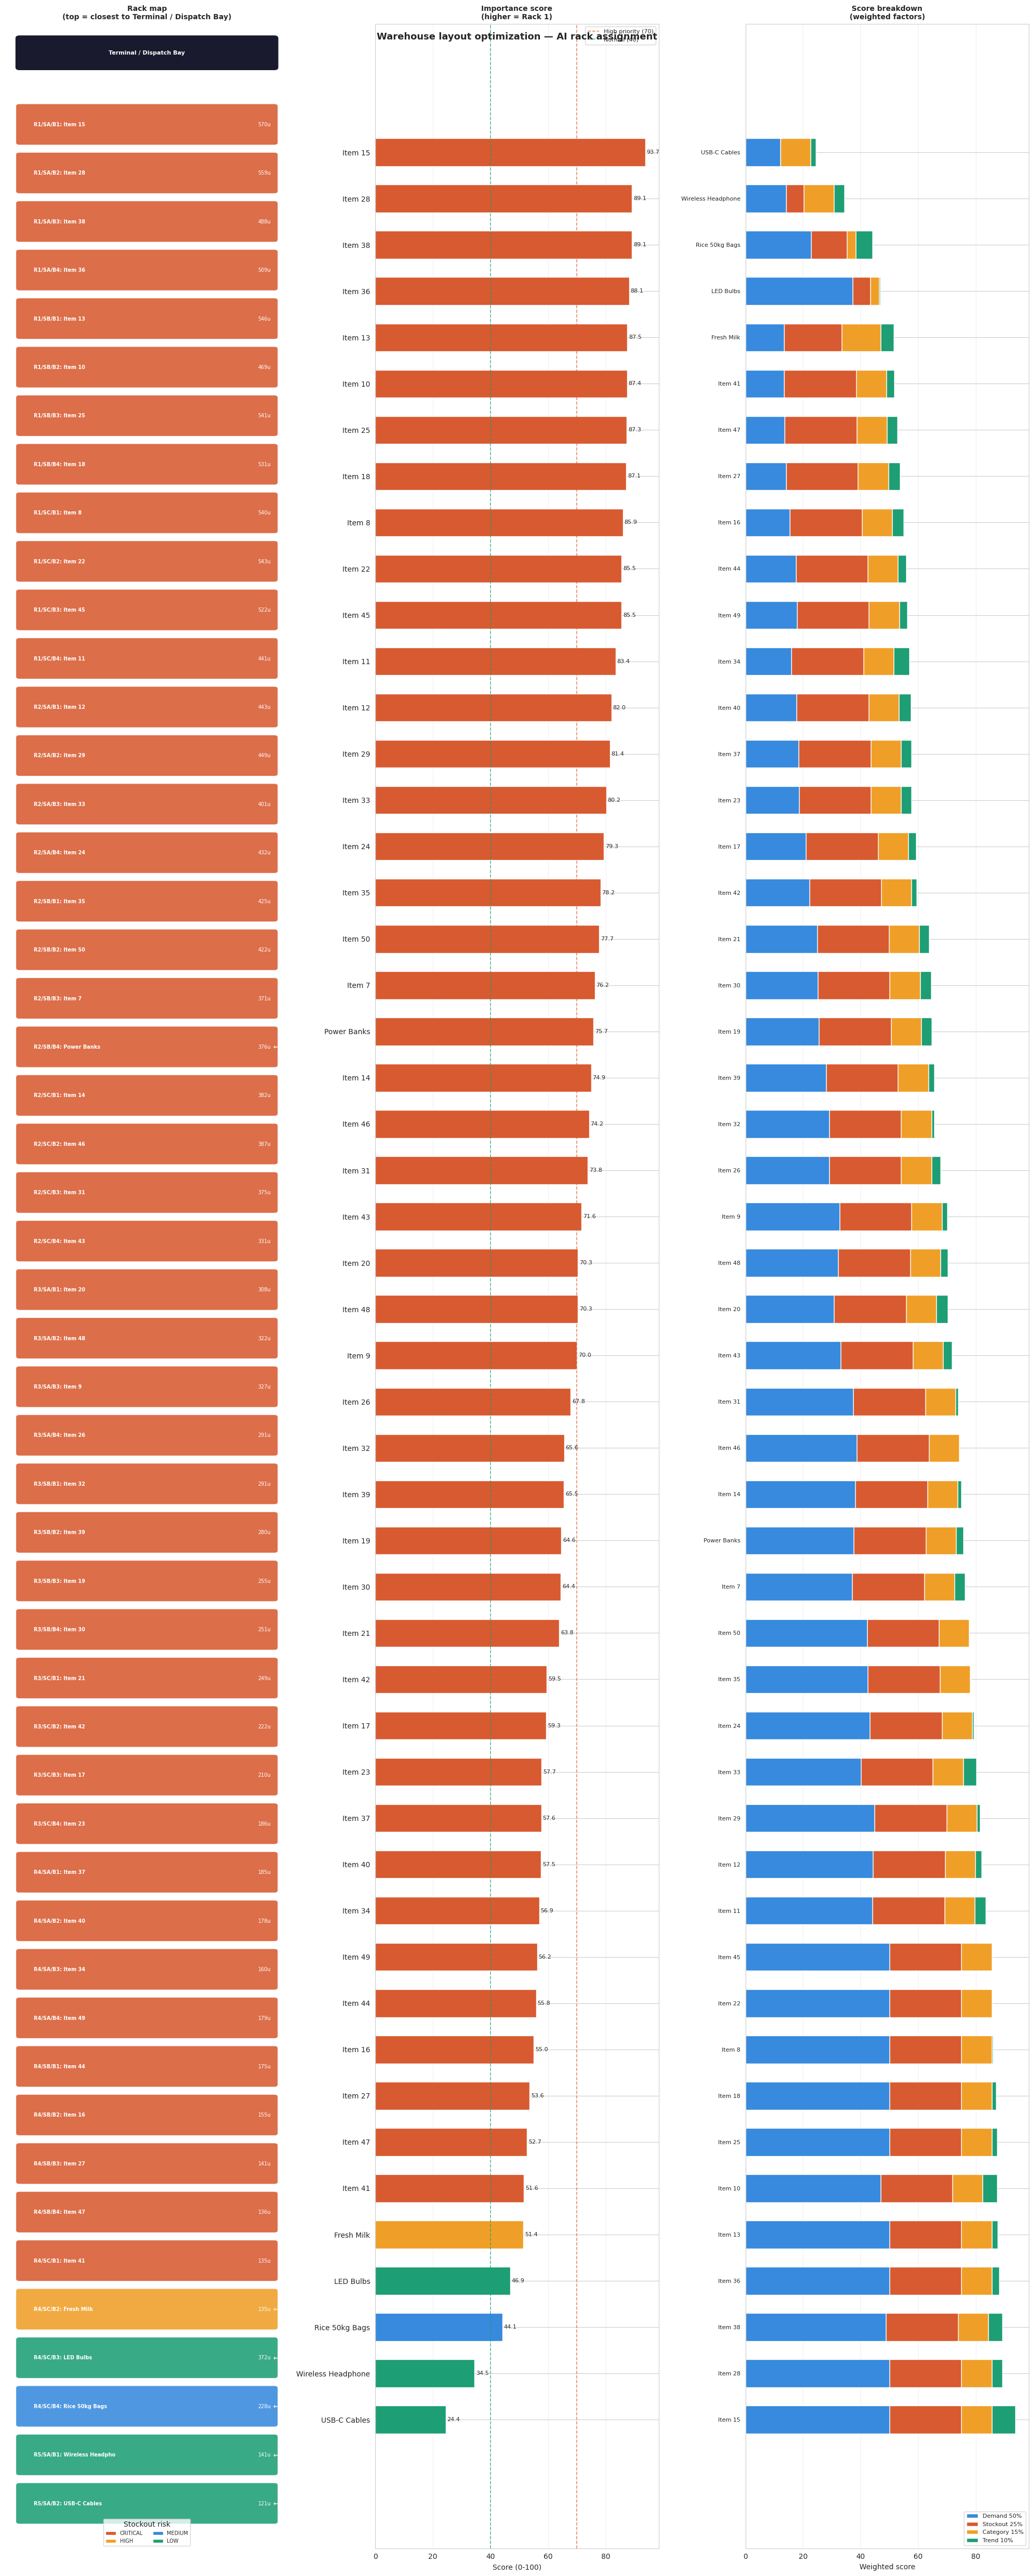


Graph saved: layout_20260424_0629.png


In [ ]:
import matplotlib.patches as mpatches
from datetime import datetime

def optimize_warehouse_layout(df, xgbmodel, products_meta,
                               num_racks=6,
                               num_shelves=3,
                               num_boxes=4,
                               dispatch_label='Terminal / Dispatch Bay'):

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_mean_90','rolling_std_7',
                'trend_direction','yoy_growth']

    risk_colors = {
        'CRITICAL': '#D85A30',
        'HIGH':     '#EF9F27',
        'MEDIUM':   '#378ADD',
        'LOW':      '#1D9E75',
    }

    print("\n" + "="*70)
    print("WAREHOUSE LAYOUT OPTIMIZER")
    print(f"Processing {df['item'].nunique()} products from dataset...")
    print("="*70)

    results = []

    for item_id, group in df.groupby('item'):

        latest  = group.sort_values('date').iloc[-1]
        meta    = products_meta.get(item_id, {})
        name    = meta.get('name',          f'Item {item_id}')
        cat     = meta.get('category',      'Electronics')
        stock   = meta.get('current_stock', 0)
        c_rack  = meta.get('current_rack',  'Unassigned')

        feature_row   = latest[FEATURES].values.reshape(1, -1)
        weekly_demand = round(float(xgbmodel.predict(feature_row)[0]))
        daily_rate    = weekly_demand / 7
        days_left     = round(stock / max(daily_rate, 0.1))
        trend_val     = float(latest['trend_direction'])

        if days_left <= 3:
            risk = 'CRITICAL'
        elif days_left <= 7:
            risk = 'HIGH'
        elif days_left <= 14:
            risk = 'MEDIUM'
        else:
            risk = 'LOW'

        demand_score   = min(100, (weekly_demand / 500) * 100)

        stockout_score = (100 if days_left <= 3  else
                          80  if days_left <= 7  else
                          50  if days_left <= 14 else
                          25  if days_left <= 30 else 0)

        category_score = {'Perishables':90,'Electronics':70,
                          'Fragile':60,'Bulk':20}.get(cat, 50)

        trend_score    = min(100, max(0, 50 + (trend_val * 2)))

        importance     = round(
            demand_score   * 0.50 +
            stockout_score * 0.25 +
            category_score * 0.15 +
            trend_score    * 0.10, 2
        )

        results.append({
            'item_id':        item_id,
            'name':           name,
            'category':       cat,
            'current_stock':  stock,
            'weekly_demand':  weekly_demand,
            'daily_rate':     round(daily_rate, 1),
            'days_left':      days_left,
            'stockout_risk':  risk,
            'trend':          'rising' if trend_val > 0 else 'falling',
            'trend_val':      trend_val,
            'importance':     importance,
            'current_rack':   c_rack,
            'score_breakdown': {
                'demand':   round(demand_score   * 0.50, 1),
                'stockout': round(stockout_score * 0.25, 1),
                'category': round(category_score * 0.15, 1),
                'trend':    round(trend_score    * 0.10, 1),
            }
        })

    results.sort(key=lambda x: x['importance'], reverse=True)

    slots_per_rack = num_shelves * num_boxes

    for i, p in enumerate(results):
        rack_num    = min(i // slots_per_rack + 1, num_racks)
        shelf_idx   = (i % slots_per_rack) // num_boxes
        box_num     = (i % num_boxes) + 1
        shelf_label = chr(65 + shelf_idx)
        location    = f'Rack {rack_num} / Shelf {shelf_label} / Box {box_num}'

        p['assigned_rack']  = location
        p['rack_number']    = rack_num
        p['shelf_label']    = shelf_label
        p['box_num']        = box_num
        p['rack_changed']   = (p['current_rack'] != location
                               and p['current_rack'] != 'Unassigned')

    print(f"\n{'Rank':<5} {'Item':<22} {'Cat':<13} {'Demand':>8} "
          f"{'Score':>7} {'Risk':>10} {'Location':<28} {'Move?':>6}")
    print("-"*100)
    for i, p in enumerate(results):
        move = 'YES' if p['rack_changed'] else '-'
        print(f"{i+1:<5} {p['name']:<22} {p['category']:<13} "
              f"{p['weekly_demand']:>6}u  {p['importance']:>6.1f}  "
              f"{p['stockout_risk']:>10}  {p['assigned_rack']:<28} "
              f"{move:>6}")
    print("="*100)

    moved = [p for p in results if p['rack_changed']]
    print(f"\n{len(moved)} products need to move:")
    for p in moved:
        print(f"  {p['name']:<25} "
              f"{p['current_rack']} → {p['assigned_rack']}")

    fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(results))))
    fig.suptitle('Warehouse layout optimization — AI rack assignment',
                 fontsize=13, fontweight='bold')

    n = len(results)

    ax1 = axes[0]
    ax1.set_xlim(0, 4)
    ax1.set_ylim(-0.5, n + 1.5)
    ax1.axis('off')
    ax1.set_title(f'Rack map\n(top = closest to {dispatch_label})',
                  fontweight='bold', fontsize=10)

    ax1.add_patch(mpatches.FancyBboxPatch(
        (0.2, n + 0.6), 3.6, 0.6,
        boxstyle='round,pad=0.05',
        facecolor='#1a1a2e', edgecolor='#1a1a2e'
    ))
    ax1.text(2, n + 0.9, dispatch_label,
             ha='center', va='center',
             fontsize=8, fontweight='bold', color='white')

    for i, p in enumerate(results):
        y     = n - 1 - i
        color = risk_colors.get(p['stockout_risk'], '#9FE1CB')
        ax1.add_patch(mpatches.FancyBboxPatch(
            (0.2, y + 0.05), 3.6, 0.75,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', alpha=0.88
        ))
        ax1.text(0.4, y + 0.42,
                 f"R{p['rack_number']}/S{p['shelf_label']}/B{p['box_num']}: {p['name'][:16]}",
                 va='center', fontsize=7, color='white',
                 fontweight='bold')
        ax1.text(3.75, y + 0.42,
                 f"{p['weekly_demand']}u",
                 va='center', ha='right',
                 fontsize=7, color='white')
        if p['rack_changed']:
            ax1.text(3.78, y + 0.42, '←',
                     va='center', fontsize=9,
                     color='#FAEEDA', fontweight='bold')

    ax1.legend(handles=[
        mpatches.Patch(facecolor=c, label=r)
        for r, c in risk_colors.items()
    ], loc='lower center', fontsize=7,
       title='Stockout risk', ncol=2)

    ax2    = axes[1]
    names  = [p['name'][:18] for p in results]
    scores = [p['importance'] for p in results]
    colors = [risk_colors.get(p['stockout_risk']) for p in results]

    bars = ax2.barh(names[::-1], scores[::-1],
                    color=colors[::-1], edgecolor='white', height=0.6)
    for bar, score in zip(bars, scores[::-1]):
        ax2.text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}', va='center', fontsize=8)

    ax2.axvline(x=70, color='#D85A30', linestyle='--',
                linewidth=1.2, alpha=0.7, label='High priority (70)')
    ax2.axvline(x=40, color='#1D9E75', linestyle='--',
                linewidth=1.2, alpha=0.7, label='Normal (40)')
    ax2.set_title('Importance score\n(higher = Rack 1)',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Score (0-100)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='x')

    ax3     = axes[2]
    keys    = ['demand','stockout','category','trend']
    colors3 = ['#378ADD','#D85A30','#EF9F27','#1D9E75']
    labels3 = ['Demand 50%','Stockout 25%','Category 15%','Trend 10%']
    bottom  = np.zeros(n)
    y_pos   = np.arange(n)

    for key, col, lab in zip(keys, colors3, labels3):
        vals = [p['score_breakdown'][key] for p in results]
        ax3.barh(y_pos, vals, left=bottom,
                 color=col, label=lab,
                 edgecolor='white', height=0.6)
        bottom += np.array(vals)

    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([p['name'][:18] for p in results], fontsize=8)
    ax3.set_title('Score breakdown\n(weighted factors)',
                  fontweight='bold', fontsize=10)
    ax3.set_xlabel('Weighted score')
    ax3.legend(fontsize=8, loc='lower right')
    ax3.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    fname = f"layout_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGraph saved: {fname}")

    return results

products_meta = {
    1:  {'name':'Wireless Headphones','category':'Electronics',
         'current_stock':440,  'current_rack':'Rack 3'},
    2:  {'name':'Power Banks',        'category':'Electronics',
         'current_stock':120,  'current_rack':'Rack 5'},
    3:  {'name':'Rice 50kg Bags',     'category':'Bulk',
         'current_stock':340,  'current_rack':'Rack 1'},
    4:  {'name':'Fresh Milk',         'category':'Perishables',
         'current_stock':80,   'current_rack':'Rack 6'},
    5:  {'name':'USB-C Cables',       'category':'Electronics',
         'current_stock':1200, 'current_rack':'Rack 2'},
    6:  {'name':'LED Bulbs',          'category':'Bulk',
         'current_stock':890,  'current_rack':'Rack 4'},
}

optimized = optimize_warehouse_layout(
    df             = df,          
    xgbmodel       = xgbmodel,    
    products_meta  = products_meta,
    num_racks      = 6,
    dispatch_label = 'Terminal / Dispatch Bay'
)

In [1]:
def calculate_layout_efficiency(item_id, rack, shelf, box,
                                 df, model, products_meta,
                                 num_racks=6, num_shelves=3, num_boxes=4):

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_mean_90','rolling_std_7','trend_direction','yoy_growth']

    group         = df[df['item'] == item_id].sort_values('date')
    latest        = group.iloc[-1]
    meta          = products_meta.get(item_id, {})
    name          = meta.get('name',          f'Item {item_id}')
    cat           = meta.get('category',      'Electronics')
    stock         = meta.get('current_stock', 0)

    feature_row   = latest[FEATURES].values.reshape(1, -1)
    weekly_demand = round(float(model.predict(feature_row)[0]))
    daily_rate    = weekly_demand / 7
    days_left     = round(stock / max(daily_rate, 0.1))
    trend_val     = float(latest['trend_direction'])

    if   days_left <= 3:  stockout_risk = 'CRITICAL'
    elif days_left <= 7:  stockout_risk = 'HIGH'
    elif days_left <= 14: stockout_risk = 'MEDIUM'
    else:                 stockout_risk = 'LOW'

    demand_score   = min(100, (weekly_demand / 500) * 100)
    stockout_score = (100 if days_left <= 3  else
                       80 if days_left <= 7  else
                       50 if days_left <= 14 else
                       25 if days_left <= 30 else 0)
    category_score = {'Perishables':90,'Electronics':70,
                      'Fragile':60,'Bulk':20}.get(cat, 50)
    trend_score    = min(100, max(0, 50 + (trend_val * 2)))

    importance     = round(
        demand_score   * 0.50 +
        stockout_score * 0.25 +
        category_score * 0.15 +
        trend_score    * 0.10, 2
    )

    all_items     = df['item'].unique()
    all_imp       = {}
    for iid in all_items:
        g   = df[df['item'] == iid].sort_values('date')
        lr  = g.iloc[-1]
        m   = products_meta.get(iid, {})
        c   = m.get('category', 'Electronics')
        s   = m.get('current_stock', 0)
        fr  = lr[FEATURES].values.reshape(1, -1)
        wd  = round(float(model.predict(fr)[0]))
        dr  = wd / 7
        dl  = round(s / max(dr, 0.1))
        tv  = float(lr['trend_direction'])
        ds  = min(100, (wd / 500) * 100)
        ss  = (100 if dl<=3 else 80 if dl<=7 else 50 if dl<=14 else 25 if dl<=30 else 0)
        cs  = {'Perishables':90,'Electronics':70,'Fragile':60,'Bulk':20}.get(c, 50)
        ts  = min(100, max(0, 50 + (tv * 2)))
        all_imp[iid] = round(ds*0.50 + ss*0.25 + cs*0.15 + ts*0.10, 2)

    ranked         = sorted(all_imp, key=all_imp.get, reverse=True)
    position       = ranked.index(item_id)
    slots_per_rack = num_shelves * num_boxes
    ideal_rack     = min(position // slots_per_rack + 1, num_racks)
    ideal_shelf_i  = (position % slots_per_rack) // num_boxes
    ideal_box      = (position % num_boxes) + 1

    if cat == 'Fragile':
        ideal_shelf_i = min(1, num_shelves - 1)
    if cat == 'Perishables':
        ideal_rack = min(ideal_rack, 2)
    if cat == 'Bulk':
        ideal_rack = max(ideal_rack, 4)
    if stockout_risk == 'CRITICAL':
        ideal_rack = min(ideal_rack, 1)
    elif stockout_risk == 'HIGH':
        ideal_rack = min(ideal_rack, 2)

    ideal_shelf_label = chr(65 + ideal_shelf_i)

    shelf_idx  = ord(shelf.upper()) - 65

    rack_gap   = abs(rack - ideal_rack)
    shelf_gap  = abs(shelf_idx - ideal_shelf_i)
    box_gap    = abs(box - ideal_box)

    rack_score  = max(0, 100 - (rack_gap  / max(num_racks   - 1, 1)) * 100)
    shelf_score = max(0, 100 - (shelf_gap / max(num_shelves - 1, 1)) * 100)
    box_score   = max(0, 100 - (box_gap   / max(num_boxes   - 1, 1)) * 100)

    cat_score   = 100
    if   cat == 'Perishables' and rack > 2:
        cat_score = max(0, 100 - (rack - 2) * 25)
    elif cat == 'Bulk'        and rack < 4:
        cat_score = max(0, 100 - (4 - rack) * 20)
    elif cat == 'Fragile'     and shelf_idx != 1:
        cat_score = 55

    if   stockout_risk == 'CRITICAL' and rack > 1:
        cat_score = min(cat_score, 30)
    elif stockout_risk == 'HIGH'     and rack > 2:
        cat_score = min(cat_score, 50)

    total = round(
        rack_score  * 0.40 +
        shelf_score * 0.30 +
        box_score   * 0.20 +
        cat_score   * 0.10, 1
    )

    label = ('Excellent' if total >= 85 else
             'Good'      if total >= 70 else
             'Fair'      if total >= 50 else
             'Poor')

    curr_location  = f"Rack {rack} / Shelf {shelf.upper()} / Box {box}"
    ideal_location = f"Rack {ideal_rack} / Shelf {ideal_shelf_label} / Box {ideal_box}"

    suggestions = []
    if rack_gap > 0:
        suggestions.append(f"Move to Rack {ideal_rack} — {rack_gap} rack(s) off from XGB-optimal position")
    if shelf_gap > 0:
        suggestions.append(f"Move to Shelf {ideal_shelf_label} — demand/category mismatch")
    if box_gap > 0:
        suggestions.append(f"Move to Box {ideal_box} — accessibility mismatch")
    if cat == 'Perishables' and rack > 2:
        suggestions.append("Perishables must be in Rack 1 or 2")
    if cat == 'Fragile' and shelf_idx != 1:
        suggestions.append("Fragile items must be on Shelf B (middle)")
    if stockout_risk == 'CRITICAL' and rack > 1:
        suggestions.append("CRITICAL stockout — must be in Rack 1")
    if stockout_risk == 'HIGH' and rack > 2:
        suggestions.append("HIGH stockout risk — must be within Rack 2")

    print("\n" + "="*65)
    print(f"  LAYOUT EFFICIENCY REPORT — {name}")
    print("="*65)
    print(f"  XGB weekly demand  : {weekly_demand} units/week  ({days_left} days of stock left)")
    print(f"  Importance score   : {importance} / 100  (rank #{position+1} of {len(ranked)} products)")
    print(f"  Stockout risk      : {stockout_risk}")
    print(f"  Category           : {cat}")
    print(f"  Trend              : {'↑ rising' if trend_val > 0 else '↓ falling'}  ({trend_val:+.1f})")
    print("-"*65)
    print(f"  Current location   : {curr_location}")
    print(f"  XGB ideal location : {ideal_location}")
    print("-"*65)
    print(f"  Rack score         : {round(rack_score,1):>6} / 100  (weight 40%)")
    print(f"  Shelf score        : {round(shelf_score,1):>6} / 100  (weight 30%)")
    print(f"  Box score          : {round(box_score,1):>6} / 100  (weight 20%)")
    print(f"  Category score     : {round(cat_score,1):>6} / 100  (weight 10%)")
    print("-"*65)
    print(f"  EFFICIENCY SCORE   : {total:>6} / 100  [{label}]")
    print("="*65)
    if suggestions:
        print("  Suggestions:")
        for s in suggestions:
            print(f"    • {s}")
    else:
        print("  ✓ Placement is XGB-optimal — no changes needed.")
    print("="*65)

    return {
        'item_id':          item_id,
        'name':             name,
        'efficiency_score': total,
        'label':            label,
        'weekly_demand':    weekly_demand,
        'days_left':        days_left,
        'importance':       importance,
        'rank':             position + 1,
        'stockout_risk':    stockout_risk,
        'current_location': curr_location,
        'ideal_location':   ideal_location,
        'breakdown': {
            'rack_score':  round(rack_score,  1),
            'shelf_score': round(shelf_score, 1),
            'box_score':   round(box_score,   1),
            'cat_score':   round(cat_score,   1),
        },
        'ideal': {
            'rack':  ideal_rack,
            'shelf': ideal_shelf_label,
            'box':   ideal_box,
        },
        'suggestions': suggestions,
    }

calculate_layout_efficiency(
    item_id        = 'ITEM_42',
    rack=4, shelf='C', box=3,
    df             = df,
    model          = xgbmodel,
    products_meta  = products_meta
)

NameError: name 'df' is not defined